In [1]:
!./venv/bin/pip install crucio


[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: /Users/maxim/Documents/work/Exam_20_08_2026_3/venv/bin/python3.14 -m pip install --upgrade pip


In [2]:
from typing import Tuple
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score

from crucio import SMOTE, SMOTEENN, ICOTE, TKRKNN, ADASYN, SMOTENC, SCUT, MWMOTE, SLS, SMOTETOMEK

from IPython.display import display

RANDOM_STATE = 42
TARGET_COL = 'Outcome'


In [3]:
LEAKAGE_COLS = [
    'NS1',
    'IgG',
    'IgM',
    'Platelet_Count',
    'WBC_Count',
    'Body_Temperature',
    'Fever_Duration',
]

CATEGORICAL_COLS = ['Gender', 'AreaType', 'HouseType', 'Joint_Pain']

OUTLIER_PARAMS = {'n_neighbors': 20, 'leaf_size': 30, 'contamination': 0.05}


In [4]:
# Load dataset and inspect columns
df = pd.read_csv('data.csv')
df = df.rename(columns=lambda x: x.strip())
df = df.drop(columns=[col for col in LEAKAGE_COLS + ['District'] if col in df.columns])

poverty = pd.read_csv('area_poverty_table.csv')
df['Area_HCR'] = df['Area'].map(poverty.set_index('Area')['HCR_upper_2022'])
df.head()


,Gender,Age,Area,AreaType,HouseType,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome,Area_HCR
0,Female,45,Mirpur,Undeveloped,Building,Severe,0,0,1,0.0,0,12.6
1,Male,17,Chawkbazar,Developed,Building,NaN,1,0,0,0.0,0,7.5
2,Female,29,Paltan,Undeveloped,Other,NaN,0,0,0,0.0,0,1.0
3,Female,63,Motijheel,Developed,Other,Moderate,0,0,1,0.0,1,3.6
4,Male,22,Gendaria,Undeveloped,Building,NaN,0,0,0,0.0,0,2.4


In [5]:
def apply_outlier_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = RANDOM_STATE,
) -> Tuple[pd.DataFrame, pd.Series]:
    detector = LocalOutlierFactor(**OUTLIER_PARAMS)
    labels = detector.fit_predict(X_train)
    mask = pd.Series(labels == 1, index=X_train.index)
    X_filtered = X_train.loc[mask].copy()
    y_filtered = y_train.loc[mask].copy()
    return X_filtered, y_filtered


In [6]:
def prepare_features(df: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    """Fill the missing values and one-hot encode the categorical columns.

    Every fill value comes from `reference` (the training + validation rows), so no statistic
    of the untouched test subset ever reaches the frames used below.
    """
    out = df.copy()

    # A missing Joint_Pain means the symptom was not reported (see 02_Missing_Values)
    out["Joint_Pain"] = out["Joint_Pain"].fillna("None")
    for col in out.select_dtypes(include="number"):
        out[col] = out[col].fillna(reference[col].median())
    for col in CATEGORICAL_COLS:
        out[col] = out[col].fillna(reference[col].mode()[0])

    return pd.get_dummies(out, columns=CATEGORICAL_COLS, drop_first=True, dtype=int)


def split_train_val_test(
    df: pd.DataFrame,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """80 / 10 / 10 split with a fixed seed, so every notebook can rebuild the same subsets.

    The test subset is returned untouched and must not take part in any selection step.
    """
    df_dev, df_test = train_test_split(df, test_size=0.1, random_state=random_state)
    df_train, df_val = train_test_split(df_dev, test_size=1 / 9, random_state=random_state)
    return df_train, df_val, df_test


In [7]:
def add_area_binning(df: pd.DataFrame, poverty_df: pd.DataFrame, n_bins: int = 5) -> pd.DataFrame:
    out = df.copy()

    areas = (
        out[["Area", "Outcome"]]
        .dropna(subset=["Area"])
        .groupby("Area", as_index=False)
        .agg(n_patients=("Outcome", "size"))
        .merge(poverty_df[["Area", "HCR_upper_2022"]], on="Area", how="left")
        .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")
        .reset_index(drop=True)
    )

    def find_balanced_cuts(sizes, n_bins=5):
        sizes = np.asarray(sizes, dtype=float)
        cumulative = np.concatenate([[0], sizes.cumsum()])
        target = sizes.sum() / n_bins

        best_score, best_bounds = None, None
        for cuts in combinations(range(1, len(sizes)), n_bins - 1):
            bounds = (0,) + cuts + (len(sizes),)
            counts = np.diff(cumulative[list(bounds)])
            deviations = np.abs(counts - target)
            score = (deviations.max(), (deviations ** 2).sum())
            if best_score is None or score < best_score:
                best_score, best_bounds = score, bounds

        return list(best_bounds), best_score

    bounds, _ = find_balanced_cuts(areas["n_patients"].values, n_bins=n_bins)

    inner_edges = [
        round(
            (areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2,
            3,
        )
        for b in bounds[1:-1]
    ]

    bin_edges = [-np.inf] + inner_edges + [np.inf]
    bin_labels = [f"Q{i}" for i in range(1, n_bins + 1)]

    area_to_hcr = poverty_df.set_index("Area")["HCR_upper_2022"]
    out["Area_HCR"] = out["Area"].map(area_to_hcr)
    out["Area_bin"] = pd.cut(
        out["Area_HCR"],
        bins=bin_edges,
        labels=bin_labels,
        ordered=True,
    )

    out["Area_bin_code"] = out["Area_bin"].cat.codes
    out = out.drop(columns=["Area_bin", "Area_HCR"])

    return out


def add_age_binning(df: pd.DataFrame, balance_tolerance: float = 0.10) -> pd.DataFrame:
    """Add Age_bin using the same balanced-split logic from Feature_Engineering.ipynb."""
    out = df.copy()

    age_counts = (
        out.groupby("Age")
        .agg(n_patients=("Outcome", "size"), positive_rate=("Outcome", "mean"))
        .sort_index()
    )

    def enumerate_splits(n_groups, n_bins):
        return np.array(
            [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
            dtype=np.int32,
        )

    def score_splits(splits, group_sizes, group_positives):
        group_sizes = np.asarray(group_sizes, dtype=float)
        group_positives = np.asarray(group_positives, dtype=float)
        cum_n = np.concatenate([[0], group_sizes.cumsum()])
        cum_p = np.concatenate([[0], group_positives.cumsum()])

        n = np.diff(cum_n[splits], axis=1)
        p = np.diff(cum_p[splits], axis=1)
        total_n, total_p = group_sizes.sum(), group_positives.sum()
        target = total_n / (splits.shape[1] - 1)

        expected_pos = n * total_p / total_n
        expected_neg = n * (total_n - total_p) / total_n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nan_to_num(
                (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
            ).sum(axis=1)

        rates = np.divide(p, n, out=np.full_like(p, np.nan), where=n > 0)
        return {
            "n": n,
            "rates": rates,
            "balance_deviation": np.abs(n - target).max(axis=1),
            "rate_spread": np.nanmax(rates, axis=1) - np.nanmin(rates, axis=1),
            "chi2": chi2,
        }

    age_values = age_counts.index.to_numpy()
    age_sizes = age_counts["n_patients"].to_numpy()
    age_positives = out.groupby("Age")["Outcome"].sum().sort_index().to_numpy()

    splits = enumerate_splits(len(age_values), 5)
    scores = score_splits(splits, age_sizes, age_positives)

    tol = balance_tolerance * len(out) / 5
    allowed = np.where(scores["balance_deviation"] <= tol)[0]
    if len(allowed) == 0:
        raise ValueError("No age split satisfies the balance tolerance.")

    chosen = allowed[scores["chi2"][allowed].argmax()]
    age_bounds = splits[chosen]

    age_edges = [-np.inf] + [(age_values[b - 1] + age_values[b]) / 2 for b in age_bounds[1:-1]] + [np.inf]
    age_labels = [
        f"{age_values[age_bounds[i]]}-{age_values[age_bounds[i + 1] - 1]}"
        for i in range(5)
    ]

    out["Age_bin"] = pd.cut(out["Age"], bins=age_edges, labels=age_labels, ordered=True)
    out = pd.get_dummies(out, columns=["Age_bin"], drop_first=True, dtype=int)
    return out


def apply_binning(
    df: pd.DataFrame,
    poverty_path: str = "area_poverty_table.csv",
    ) -> pd.DataFrame:
    """The binning picked in 00_model: one ordinal Area column, one-hot Age bins.

    Area_HCR and the raw Age column are dropped, so only the binned versions reach the models.
    """
    poverty = pd.read_csv(poverty_path)
    df_binned = add_area_binning(df, poverty, n_bins=5)
    df_binned = add_age_binning(df_binned, balance_tolerance=0.10)
    return df_binned.drop(columns=["Area", "Age"])


In [8]:
# Selected features per user request
SELECTED_FEATURES = [
    'Headache',
    'Retro_Orbital_Pain',
    'Myalgia',
    'Rash',
    'Joint_Pain_None',
    'Joint_Pain_Severe',
]


In [9]:
# Prepare data
df_train_raw, df_val_raw, df_test_raw = split_train_val_test(df, RANDOM_STATE)

df_dev_raw = pd.concat([df_train_raw, df_val_raw], axis=0)
df_dev = apply_binning(prepare_features(df_dev_raw, reference=df_dev_raw))

print(f"train: {len(df_train_raw)} | val: {len(df_val_raw)} | test (untouched): {len(df_test_raw)}")

X = df_dev.drop(columns=[TARGET_COL]).copy()
y = df_dev[TARGET_COL].copy()


train: 800 | val: 100 | test (untouched): 100


In [10]:
def get_predictor_pipeline(
    X_train_raw: pd.DataFrame,
    y_train: pd.Series,
    X_test_raw: pd.DataFrame,
    y_test: pd.Series,
    balancing_model_class,
    predictor_class=GradientBoostingClassifier,
):
    """Prepare data using the shared helpers, apply the Crucio balancer,
    and return a fitted predictor plus processed train/test sets."""

    # 1) Outlier filtering on the training rows (uses shared helper)
    X_train_f, y_train_f = apply_outlier_filter(X_train_raw, y_train, random_state=RANDOM_STATE)

    # 2) Feature selection (keep consistent columns expected by the predictor)
    X_train_sel = X_train_f.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)
    X_test_sel = X_test_raw.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)

    # 3) Prepare dataframe for Crucio balancer: include the target column name
    proc_df = X_train_sel.copy().reset_index(drop=True)
    proc_df[TARGET_COL] = y_train_f.reset_index(drop=True).astype(int)

    # Check minimum sample size in each class for balancing
    min_class_count = proc_df[TARGET_COL].value_counts().min()

    # 4) Balance using the provided balancing class (Crucio API) with error handling
    X_train_balanced = X_train_sel.copy()
    y_train_balanced = y_train_f.reset_index(drop=True).astype(int)

    if min_class_count >= 2:  # Only attempt balancing if enough samples in minority class
        try:
            balanced_df = balancing_model_class().balance(proc_df, TARGET_COL)
            X_train_balanced = balanced_df.drop(columns=[TARGET_COL])
            y_train_balanced = balanced_df[TARGET_COL].astype(int)
        except Exception as e:
            # If balancing fails, fall back to unbalanced data
            print(f"Warning: {balancing_model_class().__class__.__name__} failed ({type(e).__name__}). Using unbalanced data.")
            pass
    else:
        print(f"Warning: Minority class has {min_class_count} samples. Skipping balancing.")

    # 5) Fit the predictor pipeline on balanced data
    predictor_pipeline = make_pipeline(StandardScaler(), predictor_class(random_state=RANDOM_STATE))
    predictor_pipeline.fit(X_train_balanced, y_train_balanced)

    return predictor_pipeline, X_train_balanced, y_train_balanced, X_test_sel, y_test.reset_index(drop=True)


In [11]:
balancing_models = [SMOTE, SMOTEENN, ICOTE, ADASYN, SMOTENC, SLS, SMOTETOMEK]

def evaluate_balancers(X_full, y_full, balancing_models, predictor_class=GradientBoostingClassifier, n_splits=5, random_state=RANDOM_STATE):
    """Evaluate multiple Crucio balancers using 5-fold Stratified CV for robust results.
    
    Args:
        X_full: Full feature matrix
        y_full: Full target vector
        balancing_models: List of Crucio balancer classes to evaluate
        predictor_class: sklearn model class (default: GradientBoostingClassifier)
        n_splits: Number of StratifiedKFold splits (default: 5)
        random_state: Random seed for reproducibility
    
    Returns:
        Tuple of (per-fold results dict, summary DataFrame)
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    predictor_name = predictor_class.__name__
    results = {bal_class().__class__.__name__: {"f1": [], "acc": [], "recall": [], "precision": []} for bal_class in balancing_models}
    failed_balancers = {}

    for fold_num, (train_idx, test_idx) in enumerate(skf.split(X_full, y_full), 1):
        X_train_fold = X_full.iloc[train_idx].copy()
        X_test_fold = X_full.iloc[test_idx].copy()
        y_train_fold = y_full.iloc[train_idx].copy()
        y_test_fold = y_full.iloc[test_idx].copy()

        for balancing_model_class in balancing_models:
            bal_name = balancing_model_class().__class__.__name__
            
            try:
                # Process fold: outlier filtering, imputation, feature engineering, balancing, prediction
                predictor_pipeline, X_train_bal, y_train_bal, X_test_sel, y_test_proc = get_predictor_pipeline(
                    X_train_fold, y_train_fold, X_test_fold, y_test_fold, balancing_model_class, predictor_class=predictor_class
                )

                y_test_pred = predictor_pipeline.predict(X_test_sel)

                results[bal_name]["f1"].append(f1_score(y_test_proc, y_test_pred, zero_division=0))
                results[bal_name]["acc"].append(accuracy_score(y_test_proc, y_test_pred))
                results[bal_name]["recall"].append(recall_score(y_test_proc, y_test_pred, zero_division=0))
                results[bal_name]["precision"].append(precision_score(y_test_proc, y_test_pred, zero_division=0))
            except Exception as e:
                # Track failures by balancer
                if bal_name not in failed_balancers:
                    failed_balancers[bal_name] = []
                failed_balancers[bal_name].append(fold_num)
                print(f"Fold {fold_num}: {bal_name} skipped due to {type(e).__name__}")

    # Build summary DataFrame with means and stds
    summary_data = []
    for bal_name, metrics in results.items():
        if len(metrics["f1"]) > 0:  # Only include balancers with at least one successful fold
            summary_data.append({
                'Balancer': bal_name,
                'N_folds': len(metrics["f1"]),
                'F1_mean': np.mean(metrics["f1"]), 'F1_std': np.std(metrics["f1"]),
                'Acc_mean': np.mean(metrics["acc"]), 'Acc_std': np.std(metrics["acc"]),
                'Recall_mean': np.mean(metrics["recall"]), 'Recall_std': np.std(metrics["recall"]),
                'Precision_mean': np.mean(metrics["precision"]), 'Precision_std': np.std(metrics["precision"]),
            })
        else:
            print(f"Warning: {bal_name} failed on all folds. Excluding from results.")
    
    summary_df = pd.DataFrame(summary_data).sort_values('Recall_mean', ascending=False).reset_index(drop=True)
    display(summary_df)
    
    if failed_balancers:
        print("\nBalancers with failures:")
        for bal_name, folds in failed_balancers.items():
            print(f"  {bal_name}: Folds {folds}")
    
    return results, summary_df

# Usage (5-fold Stratified CV evaluation on full engineered data):
print("Starting 5-fold Stratified CV evaluation (this may take several minutes)...")
results, summary_df = evaluate_balancers(X, y, balancing_models, predictor_class=GradientBoostingClassifier, n_splits=5, random_state=RANDOM_STATE)
print("Evaluation complete!")

Starting 5-fold Stratified CV evaluation (this may take several minutes)...


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Headache            34 non-null     float64
 1   Retro_Orbital_Pain  34 non-null     float64
 2   Myalgia             34 non-null     float64
 3   Rash                34 non-null     float64
 4   Joint_Pain_None     34 non-null     float64
 5   Joint_Pain_Severe   34 non-null     float64
dtypes: float64(6)
memory usage: 1.7 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Headache            38 non-null     float64
 1   Retro_Orbital_Pain  38 non-null     float64
 2   Myalgia             38 non-null     float64
 3   Rash                38 non-null     float64
 4   Joint_Pain_None     38 non-null     float64
 5   Joint_Pain_Severe   38 non-null     float64
dtypes: float64(6)
memory usage: 1.9 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Headache            34 non-null     float64
 1   Retro_Orbital_Pain  34 non-null     float64
 2   Myalgia             34 non-null     float64
 3   Rash                34 non-null     float64
 4   Joint_Pain_None     34 non-null     float64
 5   Joint_Pain_Severe   34 non-null     float64
dtypes: float64(6)
memory usage: 1.7 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Headache            36 non-null     float64
 1   Retro_Orbital_Pain  36 non-null     float64
 2   Myalgia             36 non-null     float64
 3   Rash                36 non-null     float64
 4   Joint_Pain_None     36 non-null     float64
 5   Joint_Pain_Severe   36 non-null     float64
dtypes: float64(6)
memory usage: 1.8 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Headache            38 non-null     float64
 1   Retro_Orbital_Pain  38 non-null     float64
 2   Myalgia             38 non-null     float64
 3   Rash                38 non-null     float64
 4   Joint_Pain_None     38 non-null     float64
 5   Joint_Pain_Severe   38 non-null     float64
dtypes: float64(6)
memory usage: 1.9 KB
None


,Balancer,N_folds,F1_mean,F1_std,Acc_mean,Acc_std,Recall_mean,Recall_std,Precision_mean,Precision_std
0,SMOTEENN,5,0.954517,0.014297,0.952222,0.014316,0.951667,0.027145,0.957946,0.013958
1,ICOTE,5,0.952172,0.015833,0.950000,0.015316,0.947478,0.035228,0.957943,0.013518
2,SMOTE,5,0.952095,0.015778,0.950000,0.015316,0.945373,0.034214,0.959893,0.014123
3,SMOTENC,5,0.952095,0.015778,0.950000,0.015316,0.945373,0.034214,0.959893,0.014123
4,SLS,5,0.952095,0.015778,0.950000,0.015316,0.945373,0.034214,0.959893,0.014123
5,ADASYN,5,0.949581,0.019218,0.947778,0.018791,0.937018,0.038149,0.963469,0.010207
6,SMOTETOMEK,5,0.946443,0.014131,0.944444,0.013608,0.932807,0.032932,0.961459,0.012945


Evaluation complete!


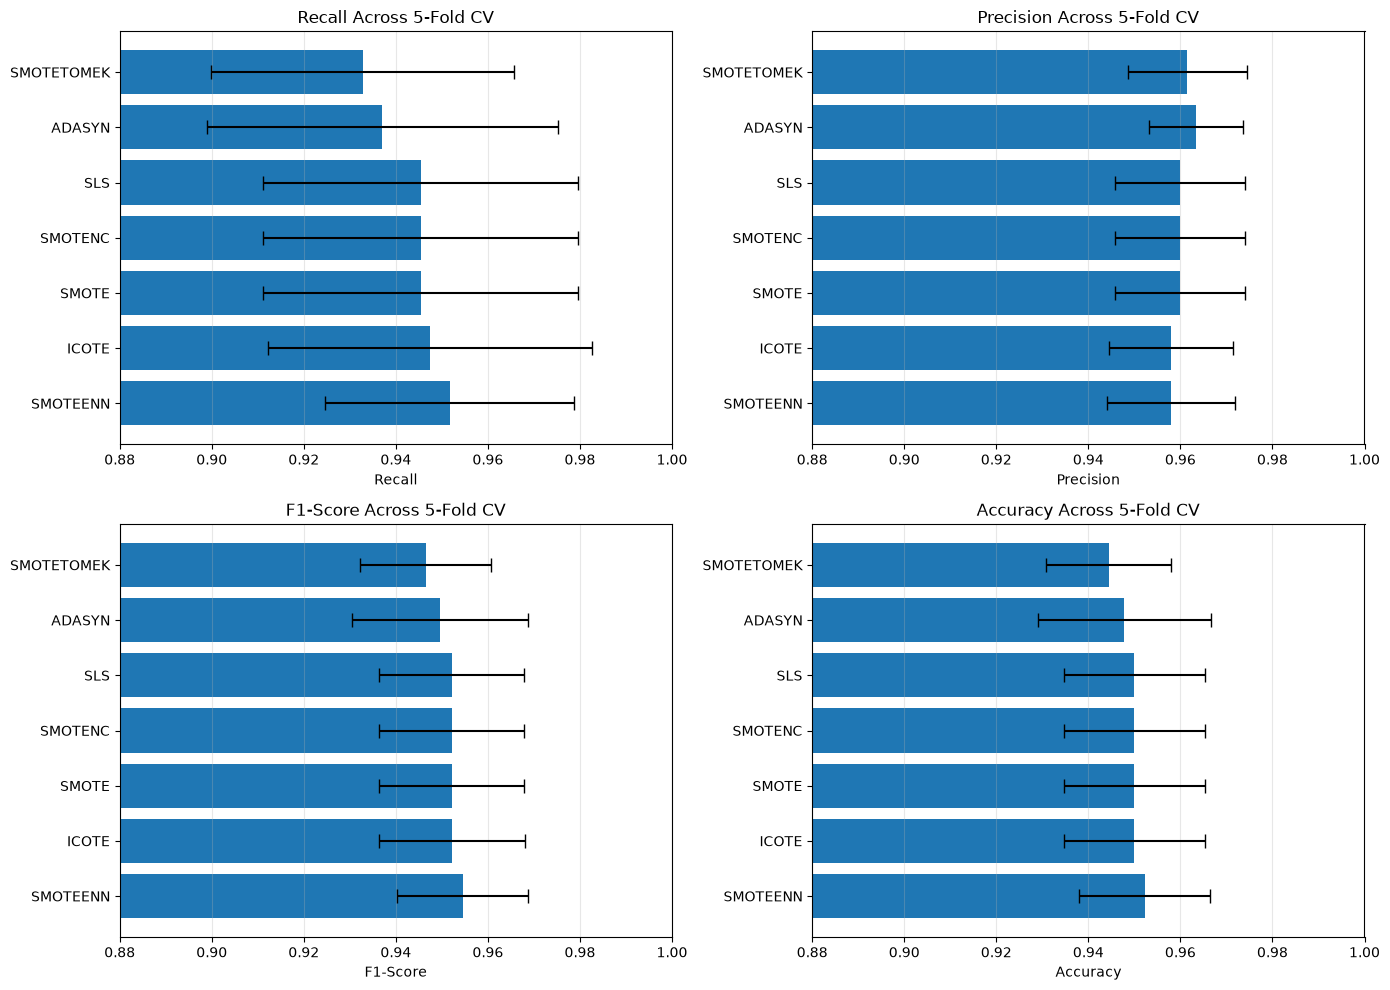

\n5-Fold Stratified CV Results for Balancing Methods:


,Balancer,N_folds,F1_mean,F1_std,Acc_mean,Acc_std,Recall_mean,Recall_std,Precision_mean,Precision_std
0,SMOTEENN,5,0.9545,0.0143,0.9522,0.0143,0.9517,0.0271,0.9579,0.0140
1,ICOTE,5,0.9522,0.0158,0.9500,0.0153,0.9475,0.0352,0.9579,0.0135
2,SMOTE,5,0.9521,0.0158,0.9500,0.0153,0.9454,0.0342,0.9599,0.0141
3,SMOTENC,5,0.9521,0.0158,0.9500,0.0153,0.9454,0.0342,0.9599,0.0141
4,SLS,5,0.9521,0.0158,0.9500,0.0153,0.9454,0.0342,0.9599,0.0141
5,ADASYN,5,0.9496,0.0192,0.9478,0.0188,0.9370,0.0381,0.9635,0.0102
6,SMOTETOMEK,5,0.9464,0.0141,0.9444,0.0136,0.9328,0.0329,0.9615,0.0129


In [12]:
def plot_balancer_comparison(summary_df):
    """Plot 2x2 grid of balancer performance metrics across 5-fold CV."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = [
        ('Recall_mean', 'Recall_std', 'Recall'),
        ('Precision_mean', 'Precision_std', 'Precision'),
        ('F1_mean', 'F1_std', 'F1-Score'),
        ('Acc_mean', 'Acc_std', 'Accuracy'),
    ]
    
    for ax, (mean_col, std_col, title) in zip(axes.flatten(), metrics):
        ax.barh(summary_df['Balancer'], summary_df[mean_col], xerr=summary_df[std_col], capsize=5)
        ax.set_xlabel(title)
        ax.set_title(f'{title} Across 5-Fold CV')
        ax.set_xlim(0.88, 1)
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Display comparison plot
plot_balancer_comparison(summary_df)

# Display detailed summary table
pd.set_option('display.float_format', '{:.4f}'.format)
print("\\n5-Fold Stratified CV Results for Balancing Methods:")
display(summary_df)

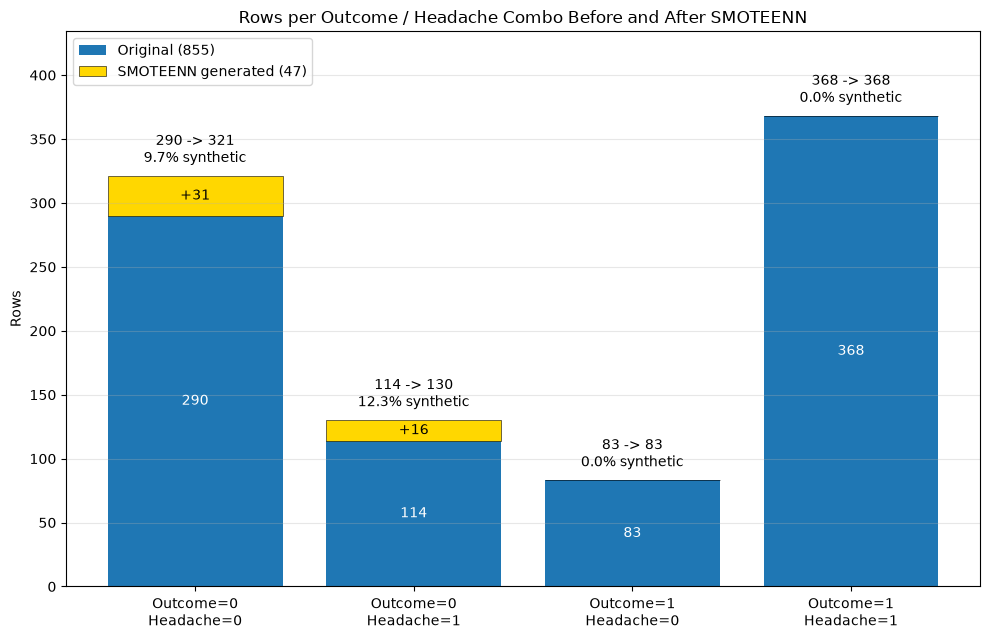

In [75]:
PLOT_COLS = ['Outcome', 'Headache']

best_balancer_name = summary_df.loc[0, 'Balancer']
best_balancer_class = {bal().__class__.__name__: bal for bal in balancing_models}[best_balancer_name]

X_filtered, y_filtered = apply_outlier_filter(X, y)
X_selected = X_filtered.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)
proc_df = X_selected.copy()
proc_df[TARGET_COL] = y_filtered.reset_index(drop=True).astype(int)

balancer = best_balancer_class()
balanced_df = balancer.balance(proc_df.copy(), TARGET_COL)
synthetic_df = pd.DataFrame(balancer.synthetic_data, columns=SELECTED_FEATURES).round()
synthetic_df[TARGET_COL] = proc_df[TARGET_COL].value_counts().idxmin()

combo_index = pd.MultiIndex.from_product([[0, 1]] * len(PLOT_COLS), names=PLOT_COLS)
original_counts = proc_df[PLOT_COLS].astype(int).groupby(PLOT_COLS).size().reindex(combo_index, fill_value=0)
synthetic_counts = synthetic_df[PLOT_COLS].astype(int).groupby(PLOT_COLS).size().reindex(combo_index, fill_value=0)

labels = ['\n'.join(f'{col}={value}' for col, value in zip(PLOT_COLS, combo)) for combo in combo_index]
original = original_counts.to_numpy()
synthetic = synthetic_counts.to_numpy()
total = original + synthetic
positions = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.bar(positions, original, color='tab:blue', label=f'Original ({original.sum()})')
ax.bar(positions, synthetic, bottom=original, color='gold', edgecolor='black', linewidth=0.4,
       label=f'{best_balancer_name} generated ({synthetic.sum()})')

for pos, orig, syn, tot in zip(positions, original, synthetic, total):
    ax.text(pos, orig / 2, f'{orig}', ha='center', va='center', color='white')
    if syn > 0:
        ax.text(pos, orig + syn / 2, f'+{syn}', ha='center', va='center', color='black')
    ax.text(pos, tot + total.max() * 0.02, f'{orig} -> {tot}\n{syn / tot * 100:.1f}% synthetic',
            ha='center', va='bottom')

ax.set_xticks(positions, labels)
ax.set_ylabel('Rows')
ax.set_ylim(0, total.max() * 1.18)
ax.set_title(f'Rows per {" / ".join(PLOT_COLS)} Combo Before and After {best_balancer_name}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
